In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from scipy.special import gamma
from scipy.integrate import quad
from scipy.stats import pearsonr, t as student_t
import re

In [3]:
def bayes_factor_JZS(n, k, R2):
    """Compute JZS Bayes Factor for simple regression.
    n: len(data)
    k: number of predictors
    R2: coef of determination"""

    def integrand(g):
        return (1 + g)**((n - k - 1)/2) * (1 + (1 - R2)*g)**(-(n-1)/2) * g**(-3/2) * np.exp(-n/(2*g))
    integral, _ = quad(integrand, 0, np.inf, limit=200)
    BF = ((n/2)**(k/2) * gamma((k+1)/2)) / (np.sqrt(np.pi)*gamma(k/2)) * integral
    return BF

def bayes_factor_JZS_partial(n, k_1, k_0, R2_1, R2_0):
    """Bayes Factor for added value of a predictor in multivariate regression.
    n: len(data)
    k_1: number of predictors for first hypothesis
    k_2: number of predictors for 2nd hypothesis
    R2_1: coef of determination for 1st hypothesis
    R2_2: coef of determination for 2nd hypothesis"""
    
    def integrand(g, n, k, R2):
        return (1 + g)**((n - k - 1)/2) * (1 + (1 - R2)*g)**(-(n-1)/2) * g**(-3/2) * np.exp(-n/(2*g))
    
    integral_1, _ = quad(integrand, 0, np.inf, args=(n, k_1, R2_1), limit=200)
    integral_0, _ = quad(integrand, 0, np.inf, args=(n, k_0, R2_0), limit=200)
    return integral_1 / integral_0

def regression_stats(y, X):
    """Perform linear regression and return R2 and residuals."""
        
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    beta = np.asarray(beta).ravel()
    yhat = X @ beta
    resid = y - yhat
    RSS = np.sum(resid**2)
    TSS = np.sum((y - np.mean(y))**2)
    R2 = 1 - RSS / TSS
    return R2, beta, resid
    

from Functions import lin_model_fast, conditioning_everything_fast, plot_map_circ, subplots_map_circ, df_xr_prep

In [4]:
##for maps get BF as array already...

def compute_regression_bf_p(y, x_main, *x_controls):
    """
    Multiple regression:
    y ~ x_main + controls

    Returns:
    r_main_equiv, BF10, p_main
    """

    # stack design matrix
    X_list = [x_main] + list(x_controls) if x_controls is not None else [x_main]
    X = np.stack(X_list, axis=1)

    # mask NaNs
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y_ = y[mask]
    X = X[mask]

    n = y.size
    k = X.shape[1]

    if n < (k + 3):
        return np.nan, np.nan, np.nan

    # regression
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    beta = np.asarray(beta).ravel()
    yhat = X @ beta

    resid = y - yhat
    RSS = np.sum(resid**2)
    TSS = np.sum((y - np.mean(y))**2)

    if TSS == 0:
        return np.nan, np.nan, np.nan

    R2 = 1 - RSS / TSS

    # t-test for main predictor (beta[0])
    XtX_inv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(XtX_inv) * RSS / (n - k))

    t_stat = beta[0] / se[0]
    p = 2 * (1 - student_t.cdf(np.abs(t_stat), df=n - k))

    # Bayes factor from R² (same idea you used before)
    BF10 = bayes_factor_JZS(n=n, k=k, R2=R2)

    return R2, BF10, p



def conditioning_everything_fast_BF(ds, driver_list, target, total_eff=False, whole_period=True, R2_int=False):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'VB', 'S_SAM']]

        else:
            if driver == 'IOD' or driver=='IOBW':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None
        if whole_period==True:

            if controls is not None:
                x_controls = [ds_rolled[var] for var in controls]
            else:
                x_controls = []
            
            print(driver, controls)

            R2, BF, p = xr.apply_ufunc(
                compute_regression_bf_p,
                ds_rolled[target],
                ds_rolled[driver],
                *x_controls,
                input_core_dims=[["year"], ["year"]] + [["year"]] * len(x_controls),
                output_core_dims=[[], [], []],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[float, float, float],
            )
            ##this gives the BF for model with all input vars against thet there is no model
            ##-->sense?
            
            mean_BF=BF
            mean_R2=R2

        ##this else part is irrelevant so far
        else:
            R2, coef, resid = sensitivity_analysis_fast(
            ds_rolled,
            target=target,
            driver=driver,
            controls=controls
            )
            
            mean_coef = coef.mean(dim="year")
            mean_R2=R2.mean(dim='year')

        if R2_int: 
        ##use this condition to give back only one of the regressions outputs, else it is too confusing
            results.append(mean_R2)
        else:
        ##or to give back only Bayes factor
            results.append(mean_BF)

        print(f"{driver} done")

    return results

In [5]:
era_SON_df=pd.read_csv('~/work/data_ready/5_with_VB.csv', index_col='Unnamed: 0')
era_SON_array=df_xr_prep(era_SON_df)
display(era_SON_array)

z500_SON=xr.open_dataset('~/work/ERA5_dyn_data_ready/z500_SON.nc')

ds_SON=xr.merge([z500_SON, era_SON_array]).dropna(dim='year')

<xarray.Dataset> Size: 7kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables:
    t_Andes        (year) float64 584B -1.453 -0.07061 -0.9353 ... -0.1758 nan
    precip_Andes   (year) float64 584B 0.8738 -2.068 0.7769 ... 0.6476 1.215 nan
    ENSO           (year) float64 584B 0.8577 -0.08958 0.6573 ... -0.33 nan
    IOD            (year) float64 584B 0.1126 -0.4963 0.1753 ... 3.25 0.8168 nan
    EDJ            (year) float64 584B -0.4128 -0.3213 0.5606 ... -0.763 nan
    EDJ_lat        (year) float64 584B 1.568 -1.369 0.8338 ... -0.1452 1.446 nan
    EDJ_lat_nostd  (year) float64 584B -48.64 -53.79 -49.93 ... -48.86 nan
    SPV            (year) float64 584B -1.639 0.7289 -1.065 ... -0.05547 nan
    A_SAM          (year) float64 584B -0.6832 0.7533 0.5528 ... -0.4684 nan
    S_SAM          (year) float64 584B -2.402 -0.386 -1.018 ... 0.9627 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

ENSO done
IOD done
SPV done


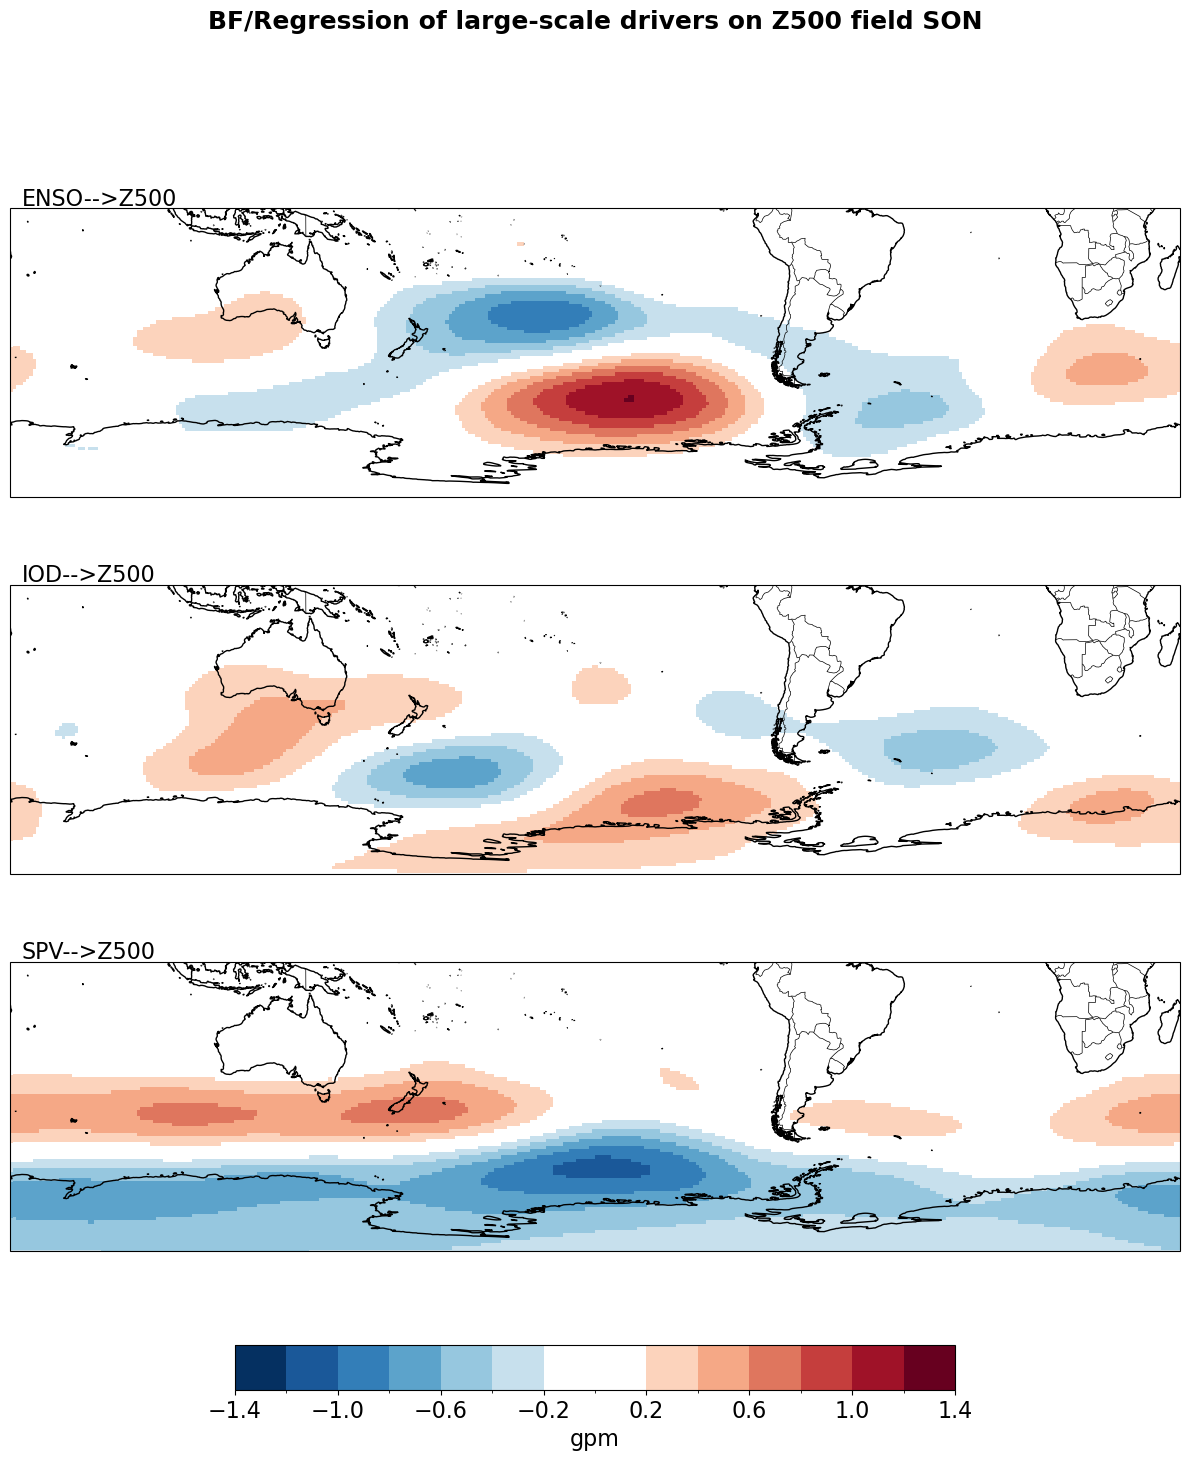

ENSO done
IOD done
SPV done


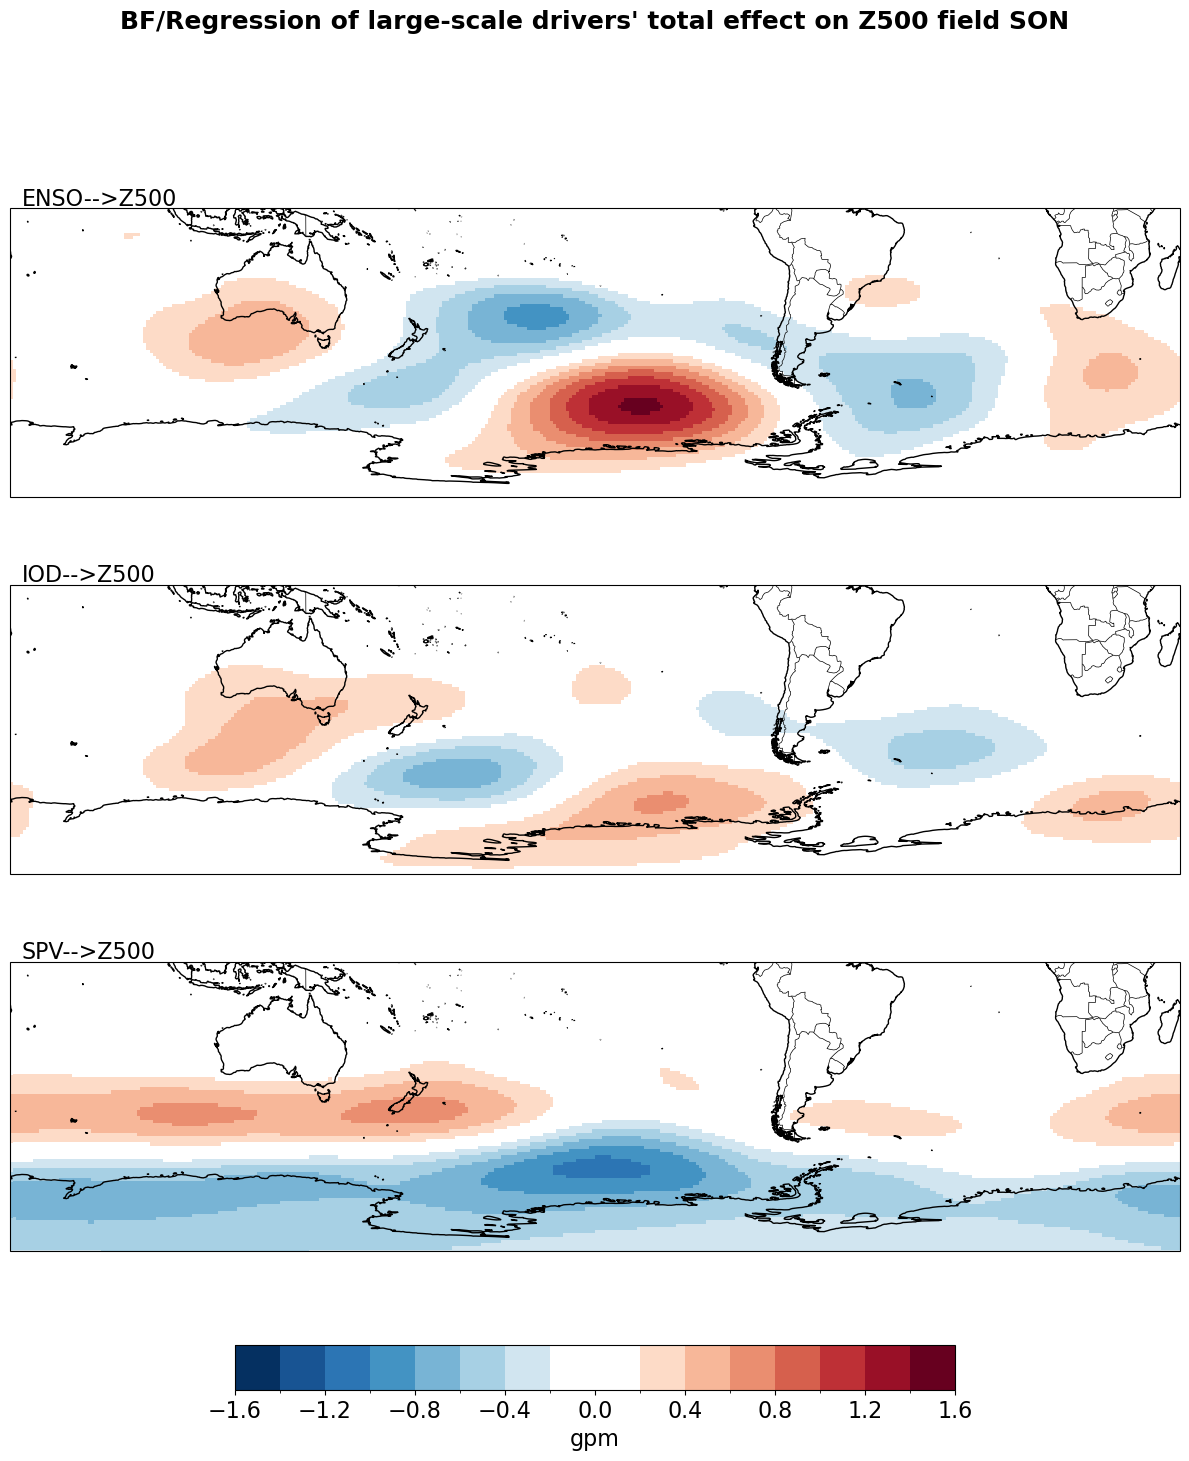

In [6]:
##check how much does large-scale drivers explain SAM pattern by regressing onto Z500
##total eff=False?
z500_drivers_coef=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV'], 'Z500', \
                                          total_eff=False, whole_period=True)

subplots_map_circ(z500_drivers_coef, ['ENSO-->Z500', 'IOD-->Z500', 'SPV-->Z500'], unit='gpm', steps=.2,\
                  heading='BF/Regression of large-scale drivers on Z500 field SON')

z500_drivers_coef_tot=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV'], 'Z500', total_eff=True,\
                                                   whole_period=True)

subplots_map_circ(z500_drivers_coef_tot, ['ENSO-->Z500', 'IOD-->Z500', 'SPV-->Z500'], unit='gpm', steps=.2,\
                  heading='''BF/Regression of large-scale drivers' total effect on Z500 field SON''')

In [7]:
##compute BF for this case
z500_drivers_BF=conditioning_everything_fast_BF(ds_SON, ['ENSO', 'IOD', 'SPV'], 'Z500', total_eff=False,\
                                                whole_period=True, R2_int=False)

z500_drivers_R2=conditioning_everything_fast_BF(ds_SON,['ENSO', 'IOD', 'SPV'], 'Z500', total_eff=False,\
                                                whole_period=True, R2_int=True )

display(z500_drivers_R2)

ENSO ['IOD', 'SPV']
ENSO done
IOD ['ENSO', 'SPV']
IOD done
SPV ['ENSO', 'IOD']
SPV done
ENSO ['IOD', 'SPV']
ENSO done
IOD ['ENSO', 'SPV']
IOD done
SPV ['ENSO', 'IOD']
SPV done


[<xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[0.11159443, 0.11151226, 0.11143527, ..., 0.11188992, 0.11179903,
         0.11170798],
        [0.11330898, 0.11304241, 0.11278119, ..., 0.11410679, 0.11384506,
         0.11357486],
        [0.11300752, 0.11260644, 0.11216628, ..., 0.11421523, 0.11382708,
         0.1133918 ],
        ...,
        [0.4070578 , 0.41002382, 0.41194583, ..., 0.3988464 , 0.40159275,
         0.40472708],
        [0.40246287, 0.40453254, 0.4064679 , ..., 0.39559986, 0.39785819,
         0.40094166],
        [0.39993431, 0.40163515, 0.40287943, ..., 0.39292169, 0.39496812,
         0.39824299]], shape=(90, 360))
 Coordinates:
   * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
   * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5,
 <xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[0.11159443, 0.11151226, 0.11143527, ..., 0.11188992, 0.11179903,
         0.11170798],
        [0.1133

In [19]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm
import cartopy.feature as cfeature

from Functions import modified_colorbar

def plot_map_circ_R2(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.PuOr,
    cbar_each=None,
    levels=None,
    BF=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values.astype(float)
    

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(subplts_num, 1, i, projection=ccrs.PlateCarree(central_longitude=-130)) 
    ##changed cols and rows here for circulation maps

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    if levels is None:
        levels = np.arange(-1, 1.01, 0.1)  # include +1
    cmap_mod=modified_colorbar(cmap, levels, center_zero=True)
    norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

    
    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap_mod)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap_mod, shading="auto")
        

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.01, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_ticks(levels)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if BF is not None:
        # ============================
        # BF thresholds (UPDATED)
        # ============================
        bf_main = 3        # moderate evidence
        bf_strong = 100    # strong evidence
        bf_null = 1/3      # evidence for null

        # Moderate evidence contour
        cs_main = ax.contour(
            BF['lon'], BF['lat'], BF,
            levels=[bf_main],
            colors='k',
            linewidths=1
        )

        # Strong evidence contour
        cs_strong = ax.contour(
            BF['lon'], BF['lat'], BF,
            levels=[bf_strong],
            colors='k',
            linewidths=2
        )

        # Evidence for null
        cs_neg = ax.contour(
            BF['lon'], BF['lat'], BF,
            levels=[bf_null],
            colors='k',
            linewidths=1,
            linestyles='dashed'
        )

        # ============================
        # Stippling
        # ============================
        lon2d, lat2d = np.meshgrid(lon, lat)

        moderate = BF > bf_main
        strong = BF > bf_strong

        # Moderate evidence → dots
        #ax.scatter(
        #    lon2d[moderate], lat2d[moderate],
        #    s=1, color='k', marker='.', alpha=0.6
        #)

        # Strong evidence → crosses
        #ax.scatter(
        #    lon2d[strong], lat2d[strong],
        #    s=2, color='k', marker='x', alpha=0.7
        #)

    return cs




def subplots_map_circ_R2(ds, title_list, cmap=plt.cm.RdBu.reversed(), unit='K', steps=0.1, cbar_each=None, heading=None, BF=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)

    #Define levels for colorbar later
    step = steps # or 0.25 if you prefer
    max_abs = np.ceil(global_max / step) * step
    #print(max_abs)
    levels = np.arange(-max_abs, max_abs + step, step)  
     
    ##Find optimal figsize
    width_per_plot = 12
    height = 5

    fig = plt.figure(figsize=(width_per_plot, len(ds)*height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        cs=plot_map_circ_R2( #get the colorbar for each subplot
        i=j+1,
        da=da,
        BF=BF[j],
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        levels=levels,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    #if global_max>levels[-1]: #if the global max exceeds the provided levels, we need to adjust them
    
    
    if not cbar_each:
        #modify colorbar
        cmap_mod = modified_colorbar(cmap, levels, center_zero=True)

        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap_mod)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        ticks = np.arange(-max_abs, max_abs + step, step*2)  
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
                
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.00001, fontweight='bold', fontsize=18)
        fig.savefig('target_maps_whole/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()



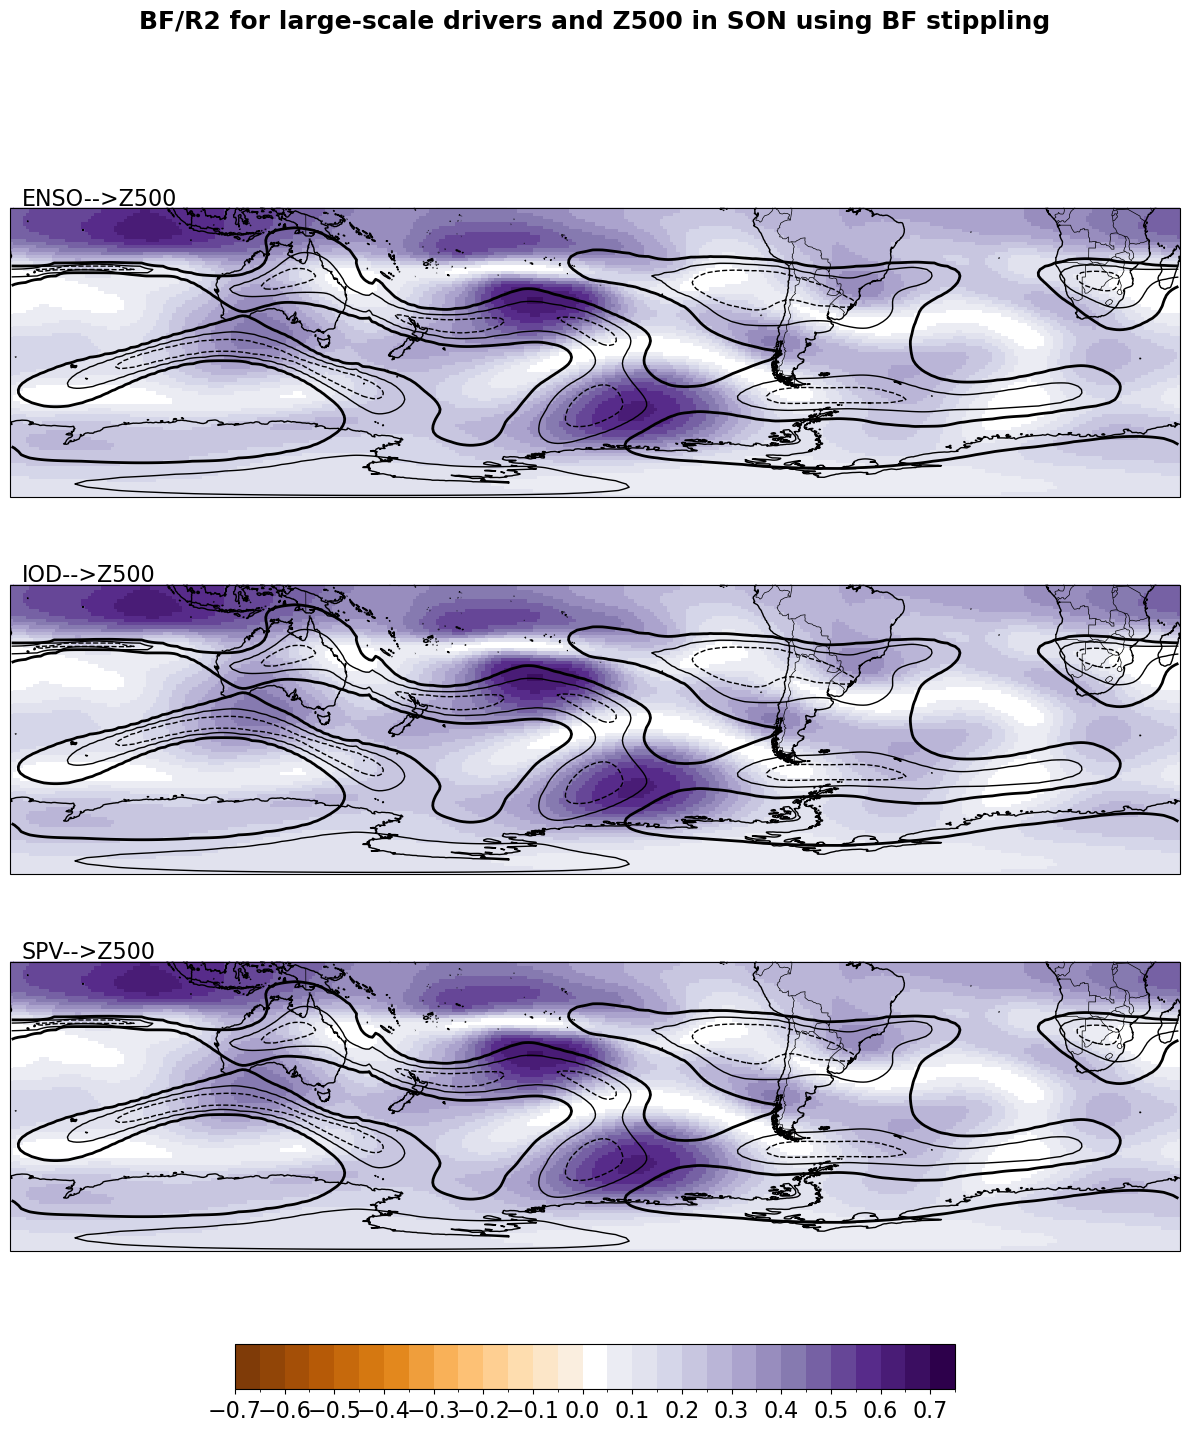

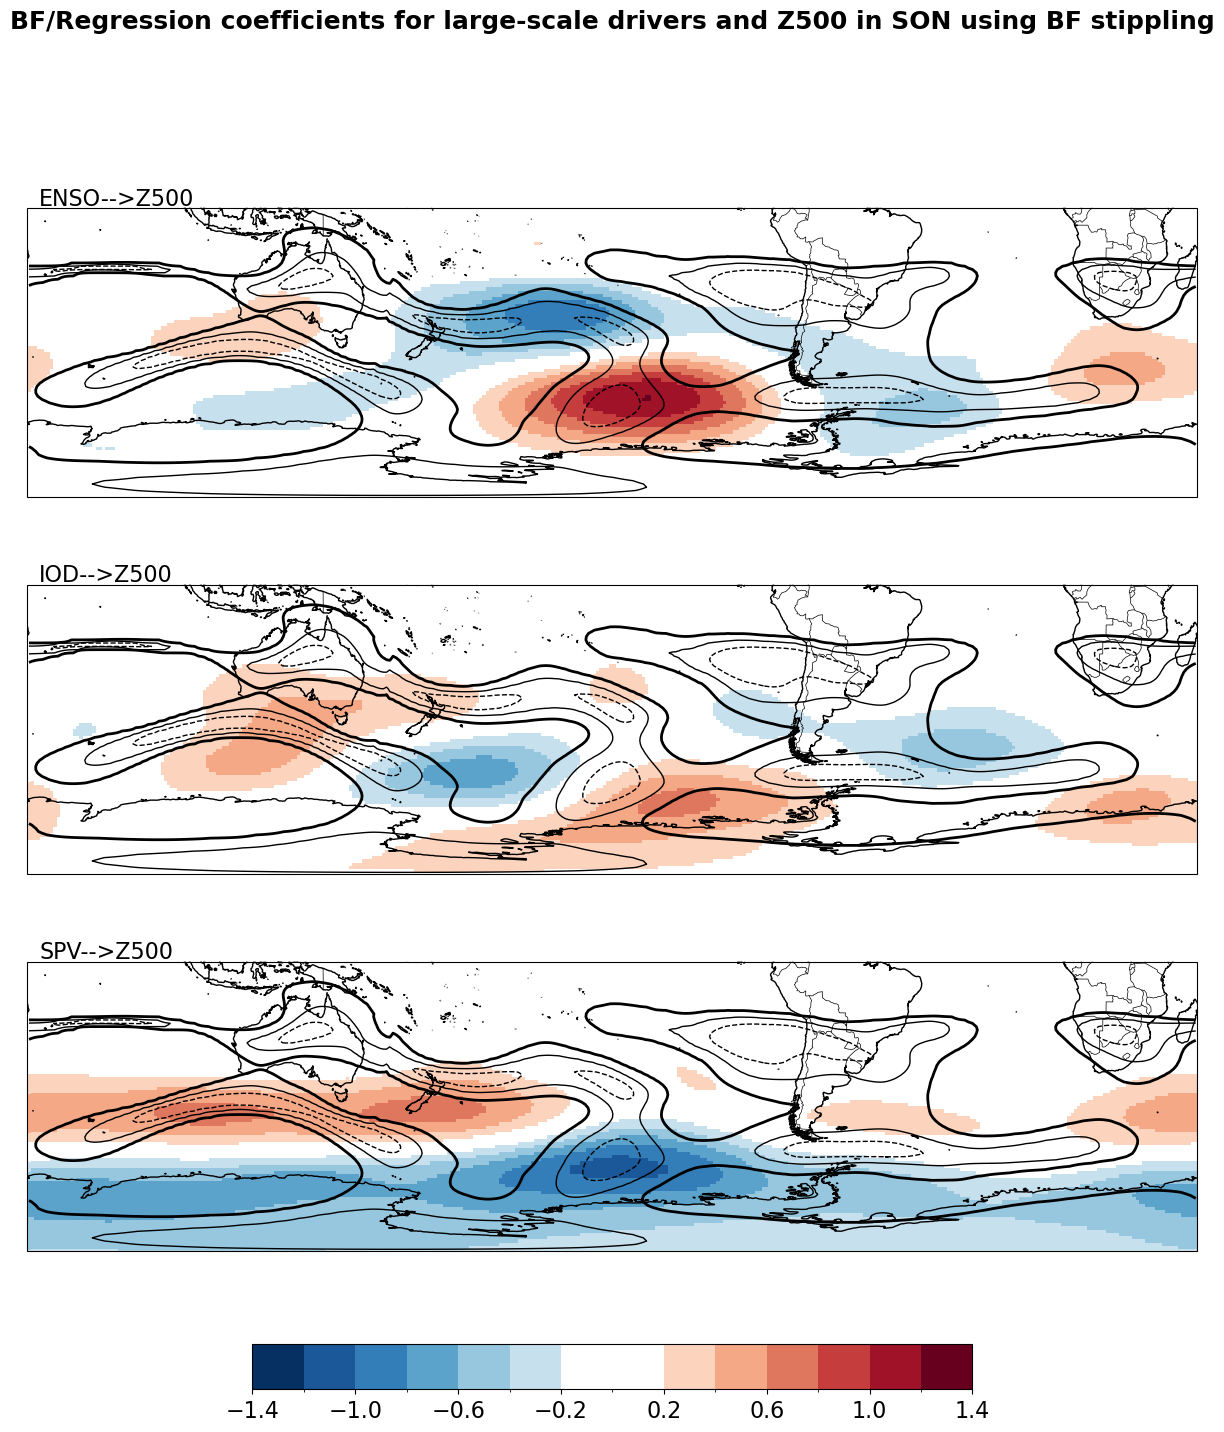

In [20]:
subplots_map_circ_R2(z500_drivers_R2, title_list=['ENSO-->Z500', 'IOD-->Z500', 'SPV-->Z500'],
                     cmap=plt.cm.PuOr, unit='', steps=0.05, \
                        heading='BF/R2 for large-scale drivers and Z500 in SON using BF stippling', BF=z500_drivers_BF)
subplots_map_circ_R2(z500_drivers_coef, title_list=['ENSO-->Z500', 'IOD-->Z500', 'SPV-->Z500'],
                     cmap=plt.cm.RdBu.reversed(), unit='', steps=0.2, \
                        heading='BF/Regression coefficients for large-scale drivers and Z500 in SON using BF stippling', BF=z500_drivers_BF)

In [10]:
def compute_bayes_factors(target_array, driver_array, *driver_controls):
    """Compute simple and multivariate Bayes factors for multiple drivers.
    Currently only for 2 drivers, but can be extended."""
    y = np.asarray(target_array).ravel()
    
    X_list = [np.asarray(driver_array), driver_controls[0]] if driver_controls else [np.asarray(driver_array)]
    X_multi = np.stack(X_list, axis=1)
    
    print(y.shape, X_multi.shape)
    # Multivariate regression
    R2_multi, BF10, _ =regression_stats(y, X_multi)

    n = len(y)
    results = {}

    for driver, X in zip(driver_list, X_list):
        R2, beta, _ =regression_stats(y, X)
        # Partial R2 for added value
        R2_multi_enso = beta_multi[0]**2 * (1 - np.corrcoef(X_list[0][:,1], X_list[1][:,1])[0,1]**2)+R2
        BF_solo = bayes_factor_JZS(n,1,R2)
        BF_multi = bayes_factor_JZS_partial(n, k_1=2, k_0=1, R2_1=R2_multi_enso, R2_0=R2_iod)

        results[driver] = (BF_solo, BF_multi)
        
    return results

def conditioning_everything_fast_multi_BF(ds, driver_list, target, total_eff=False, whole_period=True, R2_int=False):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'VB', 'S_SAM']]

        else:
            if driver == 'IOD' or driver=='IOBW':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None
        if whole_period==True:

            if controls is not None:
                x_controls = [ds_rolled[var] for var in controls]
            else:
                x_controls = []
            
            print(driver, controls)

            results = xr.apply_ufunc(
                compute_bayes_factors,
                ds_rolled[target],
                ds_rolled[driver],
                *x_controls,
                input_core_dims=[["year"], ["year"]] + [["year"]] * len(x_controls),
                output_core_dims=[[], [], []],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[float, float, float],
            )
        ##this else part is irrelevant so far
        else:
            raise NotImplementedError("Whole period=False not implemented for BF regression yet.")


        print(f"{driver} done")

    return results

BF_Z500_2_drivers=conditioning_everything_fast_multi_BF(ds_SON, ['ENSO', 'IOD'], 'Z500', total_eff=False,\
                                                whole_period=True)

ENSO ['IOD']
(70,) (70, 2)


NameError: name 'driver_list' is not defined